In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import time
import torch 
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyro.distributions as dist
from torch.distributions import Normal
mpl.rcdefaults()   # rcParams をデフォルトに戻す
from nle import NLEEstimator
from arhmm import NFlowAR1HMMEstimator
from dynamics import LotkaVolterraDynamics
from data_generation import (SwitchingSDEDataGenerator,
                             generate_true_and_obs_data,
                             generate_data_of_state)
from visualization import plot_log_prob_contour, plot_series_multi
from utils import create_ground_truth_parameters

/home/shion/Dropbox/Study/Experiment/FNSE_SSDE/.venv/FNLE_ARHMM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
"""Settings"""
seed = 42
torch.manual_seed(seed)
dynamics = LotkaVolterraDynamics()

# Initial observation
X0 = torch.tensor([1.0, 0.5], dtype=torch.float32)

# Create ground truth parameters
hmm_param_true = create_ground_truth_parameters()

# Generate observations
num_series = 5
T_obs = 2000
obs_interval = 50  # Subsample observations
n_steps_for_each_interval = T_obs // obs_interval

In [5]:
print("\nGenerating observation data...")
generator = SwitchingSDEDataGenerator(dynamics)
X_obs, Z_obs, X_true, Z_true, obs_idx_list = generate_true_and_obs_data(
    generator, num_series, hmm_param_true, T_obs, X0, obs_interval)

# Concatenate all observations for training
X_all = torch.cat(X_obs, dim=0)

# Train NLE
print("\nTraining NLE estimator...")
# ズル
sampling_dist = dist.MultivariateNormal(
    hmm_param_true['emissions'][0],
    0.3 * torch.eye(dynamics.theta_dim).to(device)
)
# sampling_dist = dist.MultivariateNormal(
#     torch.zeros_like(hmm_param_true).to(config.device),
#     0.3 * torch.eye(hmm_param_truetruetruetrue.shape[0]).to(config.device)
# )
nle = NLEEstimator(dynamics, sampling_dist=sampling_dist)
_ = nle.train(
    x_ref=X_all,
    n_params=50,
    n_steps=obs_interval,
    batch_size=256,
    lr=5e-4,
    epochs=50
)
 


Generating observation data...
  Series 1: 40 observations
  Series 2: 40 observations
  Series 3: 40 observations
  Series 4: 40 observations
  Series 5: 40 observations

Training NLE estimator...
Generating training data from 50 parameter samples...


100%|██████████| 50/50 [00:47<00:00,  1.05it/s]


Data generation took 47.82s,samples: 9950
Training NLE estimator...
 Training neural network. Epochs trained: 51
NLE training took 44.41s


In [ ]:
run_em_algorithm = True
if run_em_algorithm:
    seed = 42
    torch.manual_seed(seed)
    # Run MAP inference
    print("\nRunning EM algorithm...")
    start_time = time.time()

    # 平均0, 標準偏差1 の正規分布
    emis_init_dist = Normal(loc=0.0, scale=0.3)
    # inference = NFlowAR1HMM(nle, emis_init_dist)
    n_states = 2
    estimator = NFlowAR1HMMEstimator(nle, n_states, emis_init_dist)
    

    log_likelihoods = estimator.fit(
        X_obs, 
        n_iter=100, 
        n_grad_steps=20,
        tol=1e-4, 
        verbose=True
    )
    
    print(f"  Converged after {len(log_likelihoods)} iterations")
    print(f"  Final log-likelihood: {log_likelihoods[-1]:.2f}")
    print(f"The EM algorithm took {time.time() - start_time:.2f}s")


Running EM algorithm...
Training on 5 sequence(s)
Sequence lengths: [40, 40, 40, 40, 40]
Iteration 1: Log-likelihood = -261.978973 (avg: -1.343482)
Iteration 2: Log-likelihood = 70.258125 (avg: 0.360298)
Iteration 3: Log-likelihood = 146.658676 (avg: 0.752096)
Iteration 4: Log-likelihood = 201.534790 (avg: 1.033512)
Iteration 5: Log-likelihood = 239.512726 (avg: 1.228270)
Iteration 6: Log-likelihood = 268.907654 (avg: 1.379014)
Iteration 7: Log-likelihood = 290.851257 (avg: 1.491545)
Iteration 8: Log-likelihood = 309.923126 (avg: 1.589349)
Iteration 9: Log-likelihood = 326.456970 (avg: 1.674138)
Iteration 10: Log-likelihood = 342.018951 (avg: 1.753943)
Iteration 11: Log-likelihood = 357.579803 (avg: 1.833743)
Iteration 12: Log-likelihood = 374.063904 (avg: 1.918276)
Iteration 13: Log-likelihood = 394.108032 (avg: 2.021067)
Iteration 14: Log-likelihood = 418.515045 (avg: 2.146231)
Iteration 15: Log-likelihood = 445.888184 (avg: 2.286606)
Iteration 16: Log-likelihood = 479.618469 (avg: 

In [ ]:
state_id = 1
Z_est_list = []
T = T_obs
for series_id in range(num_series):
    values = torch.exp(estimator.log_gamma_list[series_id])[:, state_id]
    Z_est_list.append(values)

In [8]:
X_true_T = [X.T for X in X_true]

In [9]:
# X_obs = [x_true.T[:, obs_idx_list[i]]for i, x_true in enumerate(X_true)]
X_obs_T = [X.T for X in X_obs]

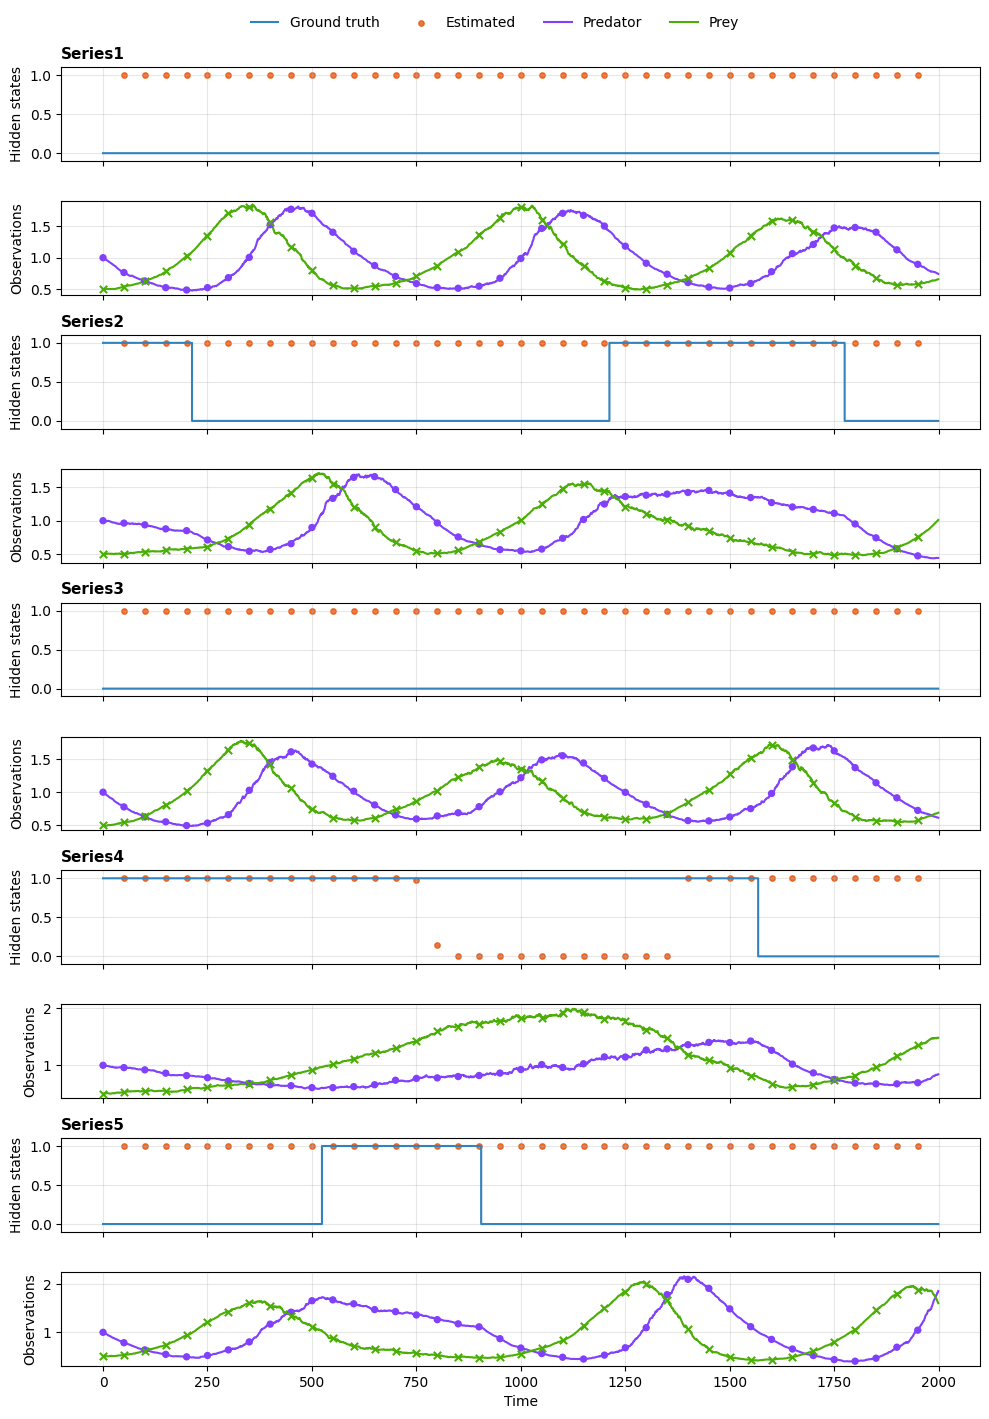

In [10]:
plot_series_multi(np.arange(T), X_true_T, X_obs_T, 
                  Z_true, Z_est_list, 
                  obs_idx_list, var_names=['Predator', 'Prey'])

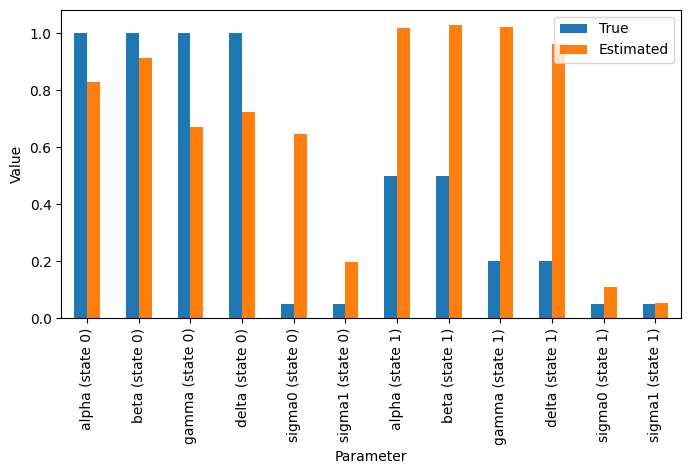

In [11]:
columns = ['alpha (state 0)', 'beta (state 0)', 'gamma (state 0)', 'delta (state 0)', 
           'sigma0 (state 0)', 'sigma1 (state 0)', 
           'alpha (state 1)', 'beta (state 1)', 'gamma (state 1)', 'delta (state 1)', 
           'sigma0 (state 1)', 'sigma1 (state 1)']
pd.DataFrame(torch.exp(torch.stack((hmm_param_true['emissions'].reshape(-1),
                                    estimator.theta.reshape(-1)))).detach(),
             index=['True', 'Estimated'],
             columns=columns).T.plot.bar(figsize=(8, 4))
plt.xlabel('Parameter')
plt.ylabel('Value')
plt.legend(loc='upper right')

In [12]:
X_obs_concat = torch.concat(X_obs).clone()

In [13]:
state = 1
# X^*
targets = generate_data_of_state(nle, state, hmm_param_true, X_obs_concat,
                                 n_steps_for_each_interval)

100it [01:23,  1.20it/s]


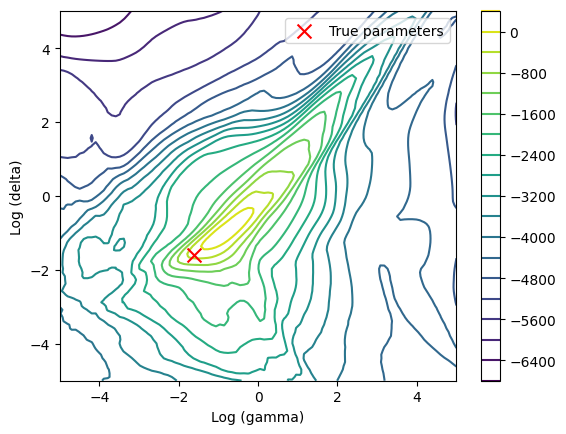

In [14]:
theta_idx_as_x = 2
theta_idx_as_y = 3
plot_log_prob_contour(nle, state, hmm_param_true, X_obs_concat, targets, theta_idx_as_x, theta_idx_as_y)